In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Bai 1

In [2]:
df=pd.read_csv(r"E:\Visualization\Lab_main\Data\diabetes.csv")
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


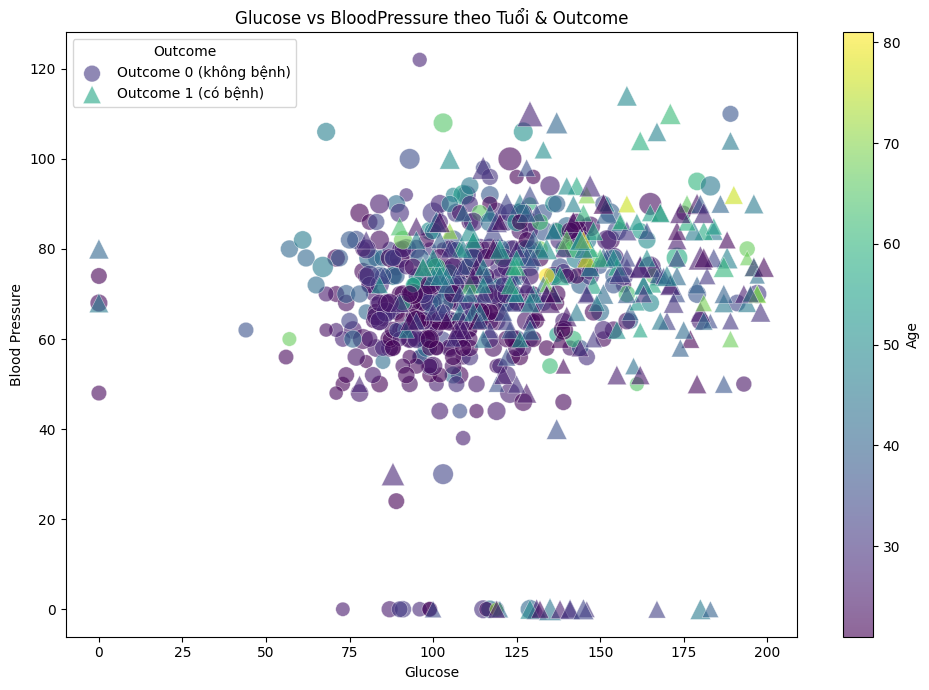

In [ ]:

# Tách data theo Outcome
df0 = df[df['Outcome'] == 0]
df1 = df[df['Outcome'] == 1]

fig, ax = plt.subplots(figsize=(10, 7))

scatter0 = ax.scatter(
    df0['Glucose'], df0['BloodPressure'],
    c=df0['Age'], cmap='viridis',
    s=df0['BMI'] * 5,         
    marker='o',
    alpha=0.6, edgecolors='white', linewidths=0.4,
    label='Outcome 0 (không bệnh)'
)

scatter1 = ax.scatter(
    df1['Glucose'], df1['BloodPressure'],
    c=df1['Age'], cmap='viridis',
    s=df1['BMI'] * 5,
    marker='^',
    alpha=0.6, edgecolors='white', linewidths=0.4,
    label='Outcome 1 (có bệnh)'
)

plt.colorbar(scatter0, ax=ax, label='Age')

ax.set_xlabel('Glucose')
ax.set_ylabel('Blood Pressure')
ax.set_title('Glucose vs BloodPressure theo Tuổi & Outcome')
ax.legend(title='Outcome', loc='upper left')

plt.tight_layout()
plt.show()

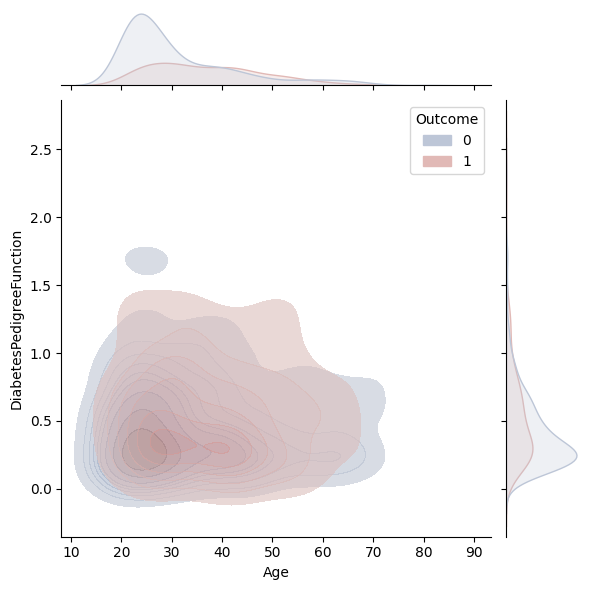

In [4]:
sns.jointplot(
    data=df, 
    x='Age', 
    y='DiabetesPedigreeFunction', 
    hue='Outcome', 
    kind='kde',     # Sử dụng Kernel Density Estimation dạng màng mờ
    fill=True,     
    alpha=0.6, 
    palette='vlag'
)


# Bai 2

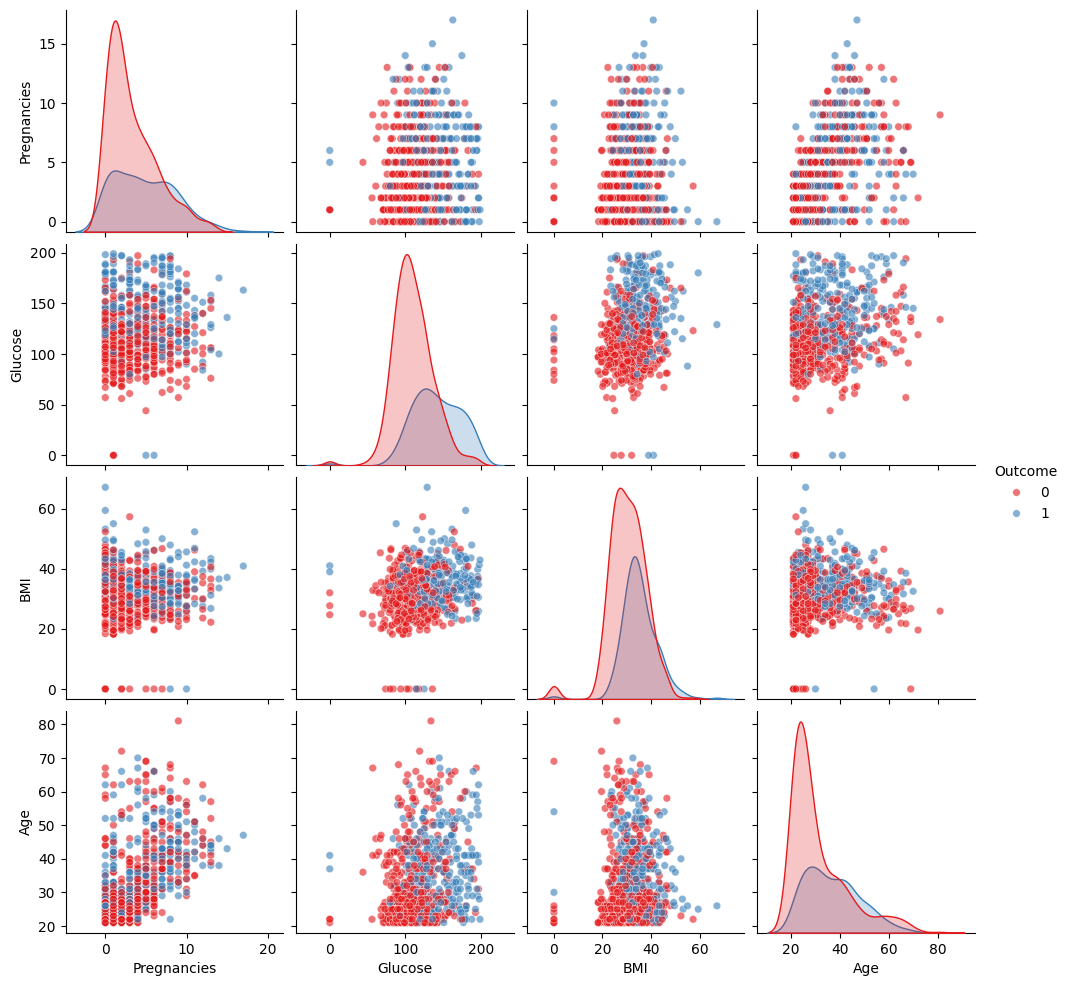

In [5]:
selected_cols = ['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome']

# Sử dụng pairplot với hue='Outcome' để tách biệt nhóm bệnh (1) và khỏe mạnh (0)
sns.pairplot(
    data=df[selected_cols], 
    hue='Outcome', 
    palette='Set1', 
    diag_kind='kde',  # Xem đường cong phân phối ở đường chéo
    plot_kws={'alpha': 0.6, 's': 30} # Làm mờ và thu nhỏ điểm chấm để tránh đè lên nhau
)
plt.show()


<Axes: xlabel='Pregnancies', ylabel='Glucose'>

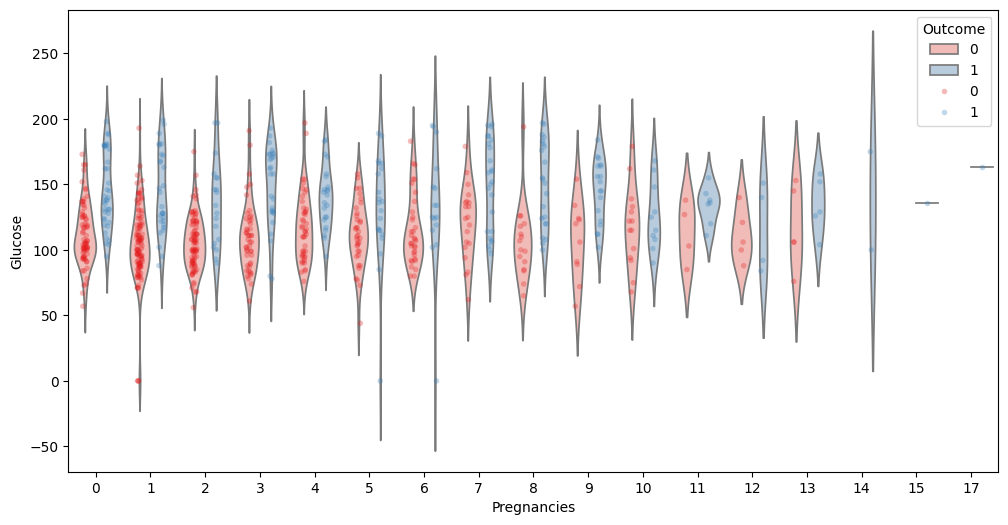

In [6]:
plt.figure(figsize=(12, 6))
# Vẽ biểu đồ vĩ cầm nền
sns.violinplot(data=df, x='Pregnancies', y='Glucose', hue='Outcome', palette='Pastel1', inner=None)
# Chèn các điểm dữ liệu thực tế lên trên
sns.stripplot(data=df, x='Pregnancies', y='Glucose', hue='Outcome', palette='Set1', dodge=True, alpha=0.3, size=4)


# Bai 3

In [7]:
df2=pd.read_csv(r"E:\Visualization\Lab_main\Data\cardio_train.csv",sep=';')
df2.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
import plotly.express as px
df2['age_years'] = (df2['age'] / 365.25).round().astype(int)

# 3. Lọc bỏ các giá trị huyết áp quá dị biệt (nhiễu nhập liệu)
df_filtered = df2[
    (df2['ap_hi'] > 40) & (df2['ap_hi'] < 200) & 
    (df2['ap_lo'] > 40) & (df2['ap_lo'] < 140)
].copy()

# 4. Lấy ngẫu nhiên mẫu 500 dòng để biểu đồ mượt, không bị lag
df_sample = df_filtered.sample(n=500, random_state=42)

# 5. Vẽ biểu đồ với Plotly bằng các cột đã tồn tại chắc chắn
fig = px.parallel_coordinates(
    df_sample, 
    color="cardio", 
    dimensions=['age_years', 'height', 'weight', 'ap_hi', 'ap_lo'], # Đã có age_years
    color_continuous_scale=[(0, 'green'), (1, 'red')],
    title="Biểu đồ Tọa độ Song song"
)

fig.show()

# Bai 4

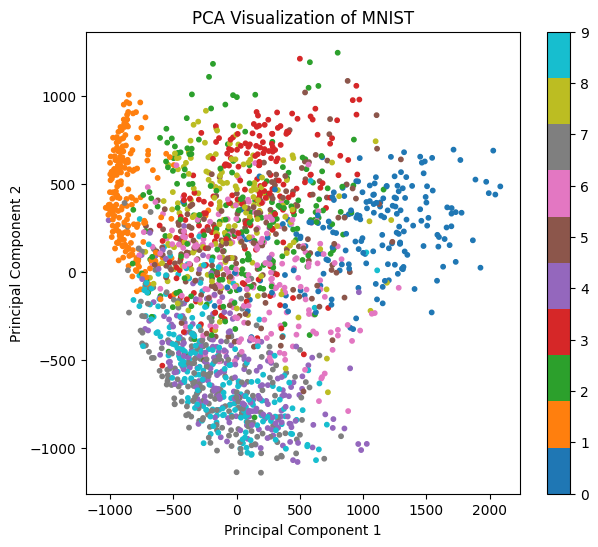

In [9]:
from sklearn.datasets import fetch_openml 
from sklearn.decomposition import PCA 
from sklearn.manifold import TSNE 
mnist = fetch_openml("mnist_784") 
X = mnist.data 
y = mnist.target 
X = X[:2000] 
y = y[:2000] 

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X) 
plt.figure(figsize=(7,6)) 
plt.scatter( 
    X_pca[:,0], 
    X_pca[:,1], 
    c=y.astype(int), 
    cmap="tab10", 
    s=10 
) 
plt.title("PCA Visualization of MNIST") 
plt.xlabel("Principal Component 1") 
plt.ylabel("Principal Component 2") 
plt.colorbar() 
plt.show() 


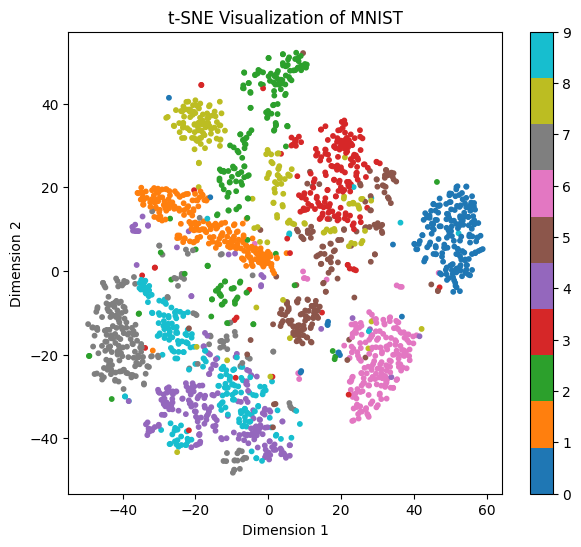

In [10]:
tsne = TSNE( 
    n_components=2, 
    perplexity=30, 
    random_state=42 
) 
 
X_tsne = tsne.fit_transform(X) 
plt.figure(figsize=(7,6)) 
plt.scatter( 
    X_tsne[:,0], 
    X_tsne[:,1], 
    c=y.astype(int), 
    cmap="tab10", 
    s=10 
) 
plt.title("t-SNE Visualization of MNIST") 
plt.xlabel("Dimension 1") 
plt.ylabel("Dimension 2") 
plt.colorbar() 
plt.show() 

# Bai lam them

In [11]:
import plotly.graph_objects as go

features = ["Glucose","BMI","Age","Pregnancies","Insulin","SkinThickness","BloodPressure","DPF"]
diabetic    = [0.83, 0.76, 0.54, 0.57, 0.49, 0.55, 0.62, 0.55]
no_diabetic = [0.57, 0.55, 0.40, 0.38, 0.28, 0.44, 0.58, 0.40]

fig = go.Figure()
for name, vals, color in [
    ("Tiểu đường",  diabetic,    "#D85A30"),
    ("Không ĐTĐ", no_diabetic, "#1D9E75"),
]:
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=features + [features[0]],
        fill="toself", name=name,
        line_color=color, fillcolor=color,
        opacity=0.4,
    ))

fig.update_layout(polar=dict(radialaxis=dict(range=[0,1])),
                  title="Radar profile — Diabetes dataset")
fig.show()

In [12]:
from ydata_profiling import ProfileReport

df = pd.read_csv(r"E:\Visualization\Lab_main\Data\diabetes.csv")
print(f"Shape: {df.shape}")
df.head()

profile = ProfileReport(
    df,
    title="Diabetes Dataset — EDA Report",

    explorative=True,         
    correlations={
        "pearson":{"calculate": True},
        "spearman":{"calculate": True},
        "kendall":{"calculate": True},
        "phi_k":{"calculate": True}, 
    },
    missing_diagrams={
        "bar": True,
        "matrix": True,
        "heatmap": True,
    },
    interactions={
        "continuous": True,    # scatter plot cho từng cặp biến
        "targets": ["Outcome"] # focus vào biến mục tiêu
    },
    vars={
        "num": {"low_categorical_threshold": 0}
    },
    plot={
        "histogram": {"bins": 30},
        "pie": {"max_unique": 10},
    },
    progress_bar=True,
)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (768, 9)


In [13]:
profile.to_file(r"E:\Visualization\Lab_main\diabetes_eda_report.html")
print("Done")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 111.09it/s]

Done
